In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import csv
from datetime import datetime
from datetime import timedelta

In [ ]:
sys.path.append('C:/Users/Vasco Zanchi/Documents/git_turbotice/')

from vasco.tools import open_csv

disk = 'D:/Grenoble/'
# if we use GreDisk it will be on 'R:'

csv_file_path = f'{disk}Gre25/Summary/Table_experiences.csv'

(dict_lists , list_categories , list_types) = open_csv.open_csv_table_experiments(csv_file_path,delimiter=',')

In [4]:
list_categories

['date',
 'experiment_num',
 'nucleation_time',
 'temperature_at_nucleation',
 'rdd_time',
 'quality_rdd',
 'h_measure_time',
 'h_avg_frac',
 'h_std_frac',
 'rdd_acq_num',
 'f_exc_moteur_Hz',
 'A_moteur_at_frac_mm',
 'Ac_ice_centre_mm_err',
 'Ac_ice_centre_mm',
 'kappa_c',
 'kappa_c_err',
 'frame_rate_Hz',
 'H_cm',
 'frame_frac',
 'i0',
 'N',
 'frac',
 'plot',
 'frac_img_file',
 'comment',
 'h_avg_rdd',
 'h_std_rdd']

In [5]:
# on ajoute le point "propre" de 2024
thicknesses_20241129 = np.array([3.12,3.04,3.74,3.28,3.52,3.15,4.16,3.79,3.85,3.84,3.59,3.55])
Ac_20241129 = 6 # mm
h_avg_20241129 = np.mean(thicknesses_20241129)
h_std_20241129 = np.std(thicknesses_20241129)
print(h_avg_20241129,'+-',h_std_20241129)



3.5524999999999998 +- 0.33169074451965047


(array([ 0,  2,  3,  5,  6,  8, 10, 13, 14, 15], dtype=int64),)
(array([ 0,  2,  3,  5,  6,  8, 10, 13, 14, 15], dtype=int64),)


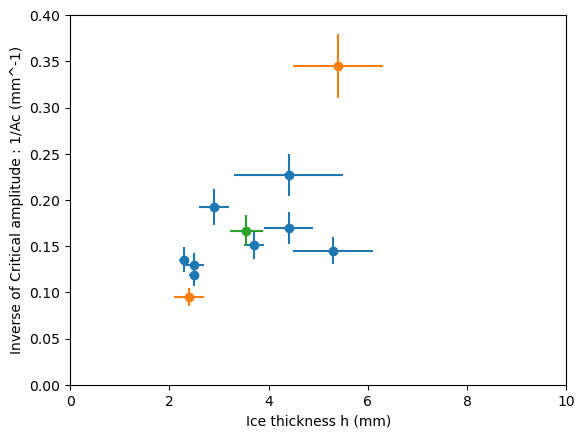

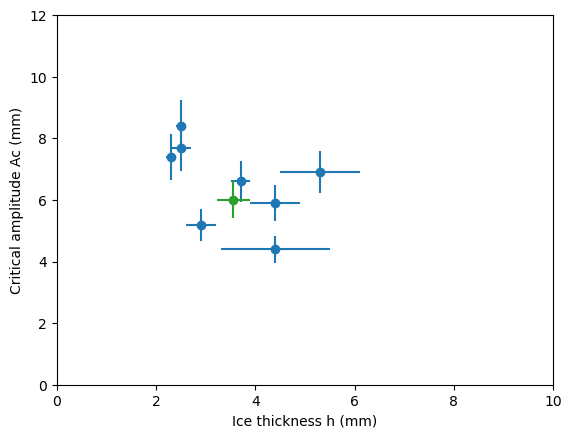

In [6]:
tab_h_avg_frac = np.array(dict_lists['h_avg_frac'])
tab_h_std_frac = np.array(dict_lists['h_std_frac'])
tab_Ac_ice_centre = np.array(dict_lists['Ac_ice_centre_mm'])
tab_err_Ac = np.array(dict_lists['Ac_ice_centre_mm_err'])

indices_to_plot = np.where(np.array(dict_lists['plot'])=='True')
print(indices_to_plot)
other_indices = np.where(np.array(dict_lists['plot'])=='False')
print(indices_to_plot)

plt.figure()
plt.errorbar(tab_h_avg_frac[indices_to_plot],1/tab_Ac_ice_centre[indices_to_plot],xerr=tab_h_std_frac[indices_to_plot],yerr=tab_err_Ac[indices_to_plot]/(tab_Ac_ice_centre[indices_to_plot]**2), marker='o',linestyle='')
plt.errorbar(tab_h_avg_frac[other_indices],1/tab_Ac_ice_centre[other_indices],xerr=tab_h_std_frac[other_indices],yerr=tab_err_Ac[other_indices]/(tab_Ac_ice_centre[other_indices]**2), marker='o',linestyle='')
plt.errorbar(h_avg_20241129,1/Ac_20241129,xerr=h_std_20241129,yerr=0.1*Ac_20241129/Ac_20241129**2,marker='o',linestyle='',color='tab:green')
plt.xlabel('Ice thickness h (mm)')
plt.ylabel('Inverse of Critical amplitude : 1/Ac (mm^-1)')
plt.xlim(0,10)
plt.ylim(0,0.4)


plt.figure()
plt.errorbar(tab_h_avg_frac[indices_to_plot],tab_Ac_ice_centre[indices_to_plot],xerr=tab_h_std_frac[indices_to_plot],yerr=tab_err_Ac[indices_to_plot], marker='o',linestyle='')
#plt.errorbar(tab_h_avg_frac[other_indices],tab_Ac_ice_centre[other_indices],xerr=tab_h_std_frac[other_indices],yerr=tab_err_Ac[other_indices], marker='o',linestyle='')
plt.errorbar(h_avg_20241129,Ac_20241129,xerr=h_std_20241129,yerr=0.1*Ac_20241129,marker='o',linestyle='',color='tab:green')
plt.xlabel('Ice thickness h (mm)')
plt.ylabel('Critical amplitude Ac (mm)')
plt.xlim(0,10)
plt.ylim(0,12)
#plt.loglog()

xdata2fit = []

#ydata2fit = 

(0.0, 10.0)

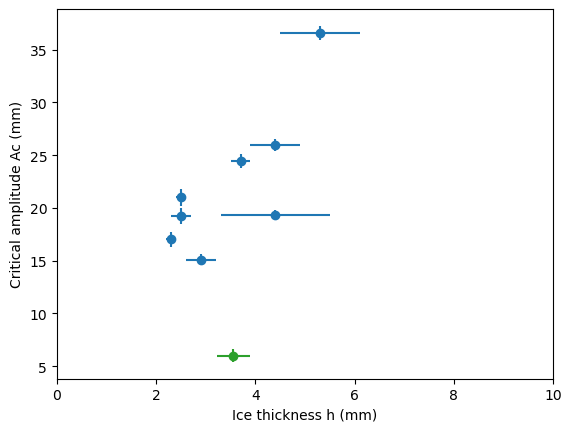

In [7]:


plt.figure()
plt.errorbar(tab_h_avg_frac[indices_to_plot],tab_Ac_ice_centre[indices_to_plot] * tab_h_avg_frac[indices_to_plot],xerr=tab_h_std_frac[indices_to_plot],yerr=tab_err_Ac[indices_to_plot], marker='o',linestyle='')
#plt.errorbar(tab_h_avg_frac[other_indices],tab_Ac_ice_centre[other_indices],xerr=tab_h_std_frac[other_indices],yerr=tab_err_Ac[other_indices], marker='o',linestyle='')
plt.errorbar(h_avg_20241129,Ac_20241129,xerr=h_std_20241129,yerr=0.1*Ac_20241129,marker='o',linestyle='',color='tab:green')
plt.xlabel('Ice thickness h (mm)')
plt.ylabel('Critical amplitude Ac (mm)')
plt.xlim(0,10)
#plt.ylim(0,12)
#plt.loglog()

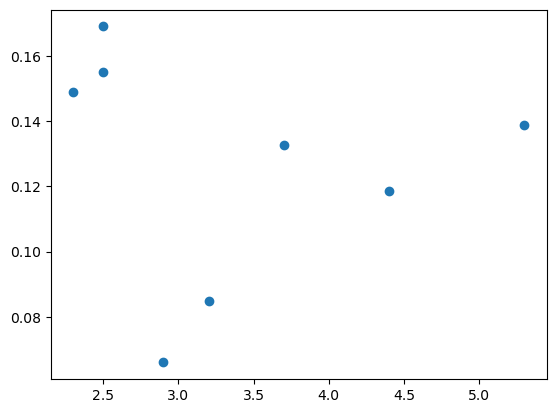

: 

In [ ]:

plt.plot(np.array(dict_lists['h_avg_frac'])[indices_to_plot],np.array(dict_lists['kappa_c'])[indices_to_plot],'o')
#plt.plot(np.array(dict_lists['h_avg_frac']),np.array(dict_lists['kappa_c']),'o')
